We are creating an email classification system, the lets you classify your email into 4 categories (spam, important, social and promotions).
The dataset contains 1M rows across six categories but we used 400k emails with four classes, beacuse of limited storage and time.
 
Dataset_link: https://www.kaggle.com/datasets/sharmajicoder/email-spam-classification

step 1: importing all the required libraries

In [30]:
# impprting all the required libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

#remove the warnings
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


step 2: imorting data, checking and removing duplicates and missing values from the data

In [31]:
#import the dataset and display basic information about it
df = pd.read_csv('email_classifier_dataset.csv')

print(" DATASET INFORMATION")

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# drop any missing values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Display first few rows
print("FIRST 5 ROWS")
df.head()

 DATASET INFORMATION
Dataset Shape: (400000, 2)

Columns: ['label', 'text']
FIRST 5 ROWS


,label,text
0,important,Let's catch up Although again development inte...
1,important,Let's catch up Organization why economy list w...
2,important,Let's catch up Relationship just discuss miss....
3,social,Someone liked your post General way training w...
4,promotion,Discount just for you Too visit money consumer...


step 3: visulaization of the label column to see the value counts of different labels

In [32]:
# check label column
df['label'].value_counts()

label
important    100000
social       100000
promotion    100000
spam         100000
Name: count, dtype: int64

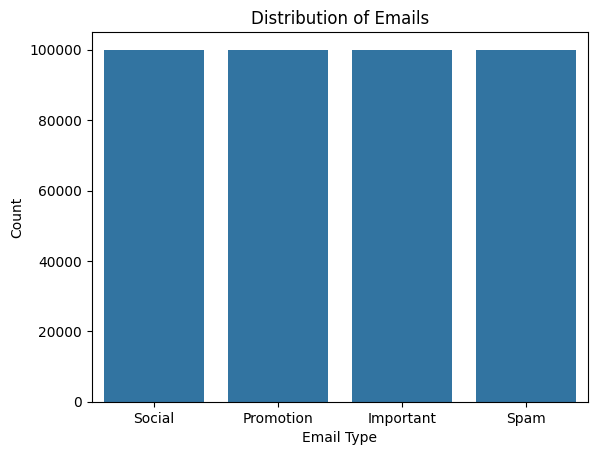

In [33]:
# check the label distribution
sns.countplot(x='label', data=df)
plt.title('Distribution of Emails')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Social','Promotion', 'Important','Spam']) 
# save the plot
plt.savefig('./figures/email_distribution.png')  
plt.show()

step 4: preprocessing the dataset for better model training and accuracy

In [34]:
# now we will start workin on features column.
# we will start with text preprocessing, we will remove special characters, stop words, and lemmatize the words.
# we will also convert the text to lowercase.
#data preprocessing with POS-based lemmatization

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls and html
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)

    # remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # normalize currency and numbers
    text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
    text = re.sub(r'\d+(\.\d+)?', ' number ', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # normalize repeated characters (gooooood → good)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # tokenize
    tokens = word_tokenize(text)

    # pos tagging
    pos_tags = pos_tag(tokens)

    # pos mapping
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'
        elif tag.startswith('V'):
            return 'v'
        elif tag.startswith('N'):
            return 'n'
        elif tag.startswith('R'):
            return 'r'
        return 'n'

    cleaned_words = []

    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            lemma = lemmatizer.lemmatize(word, get_wordnet_pos(tag))
            cleaned_words.append(lemma)

    # remove consecutive duplicate words
    final_words = []
    for word in cleaned_words:
        if not final_words or final_words[-1] != word:
            final_words.append(word)

    text = ' '.join(final_words)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [35]:
# apply the preprocessing function to the text column
df['text'] = df['text'].apply(preprocess_text)
df = df[df['text'].str.strip() != ""]

step 5: dividing the data into target and features variable for training and apply label encoder to the target column

In [36]:
# divide the dataset into features and target variable and apply label encoding to the target variable
le = LabelEncoder()
X = df['text']
y = le.fit_transform(df['label'])

In [37]:
# checking the encoded target variable to see which number is assigned to which label 
encoded_labels = dict(zip(le.classes_, le.transform(le.classes_)))
print("Encoded labels (Language → Numeric):\n", encoded_labels)

Encoded labels (Language → Numeric):
 {'important': 0, 'promotion': 1, 'social': 2, 'spam': 3}


step 6: Applying TFIDF vectorizer to the data

In [38]:
# apply tfidf vectorization to the text column and save the vectorizer for future use

vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=15000,
    max_df=0.90,
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode'
)

X = vectorizer.fit_transform(df['text'])

print("\nFeature Matrix Shape:", X.shape)
print("\nTarget Vector Shape:", y.shape)


Feature Matrix Shape: (400000, 15000)

Target Vector Shape: (400000,)


step 7: splitting the data into trainig and testing sets.

In [39]:
# apply train test split to the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# check the number of samples in training and testing sets
print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 320000
Testing Samples: 80000


step 8: Training differnt models on the same data and to see which model works best so that we can use it further.

In [40]:
# since we will be using multiple models, we will create a function to train and evaluate the models, and save the best model for future use.
models = {

    'Logistic Regression': {
        'model': LogisticRegression(
            max_iter=500,
            class_weight='balanced',
            solver='lbfgs',
        ),
        'params': {
            'C': [0.1, 1, 10]
        }
    },

    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0]
        }
    },

    'Linear SVM': {
        'model': CalibratedClassifierCV(
            LinearSVC(max_iter=2000)
        ),
        'params': {
            'estimator__C': [0.1, 1, 10]
        }
    }
}

In [41]:
# train and evaluate the models, and save the results in a list, and also save the trained models in a dictionary for future use.

results = {}
trained_models = {}
best_f1 = 0
best_model = None
best_model_name = ""

# Convert y to numeric if needed
if isinstance(y_train.iloc[0] if hasattr(y_train, 'iloc') else y_train[0], str):
    from sklearn.preprocessing import LabelEncoder
    temp_le = LabelEncoder()
    y_train = temp_le.fit_transform(y_train)
    y_test = temp_le.transform(y_test)

for name, config in models.items():
    print(f"\n📊 Training {name}...")
    
    random_search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=3,
        scoring='f1_weighted',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    random_search.fit(X_train, y_train)
    trained_model = random_search.best_estimator_
    y_pred = trained_model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'Best Params': random_search.best_params_
    }
    
    trained_models[name] = trained_model
    
    if f1 > best_f1:
        best_f1 = f1
        best_model = trained_model
        best_model_name = name
    
    print(f"   ✅ F1 Score: {f1:.4f}")

print(f"\n🏆 BEST MODEL: {best_model_name} (F1: {best_f1:.4f})")



📊 Training Logistic Regression...
   ✅ F1 Score: 1.0000

📊 Training Naive Bayes...
   ✅ F1 Score: 0.9995

📊 Training Linear SVM...
   ✅ F1 Score: 1.0000

🏆 BEST MODEL: Logistic Regression (F1: 1.0000)


In [42]:
#create the comparison table for the models
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)

print("MODEL COMPARISON RESULTS")

print(results_df)

print("BEST MODEL")

print(f"Best Model: {best_model_name}")
print(f"Best F1 Score: {best_f1:.4f}")

MODEL COMPARISON RESULTS
                    Accuracy Precision  Recall F1 Score            Best Params
Logistic Regression      1.0       1.0     1.0      1.0              {'C': 10}
Linear SVM               1.0       1.0     1.0      1.0  {'estimator__C': 0.1}
Naive Bayes           0.9995    0.9995  0.9995   0.9995         {'alpha': 1.0}
BEST MODEL
Best Model: Logistic Regression
Best F1 Score: 1.0000


step 9: Saving all the models for later use

In [43]:
# Saving models for future use

with open("models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("models/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✅ Models saved")

✅ Models saved


step 10: visualization of confusion matrix, model comparsion bar chart, perclass performance mertices and ROC Curves for each class for better understanding.

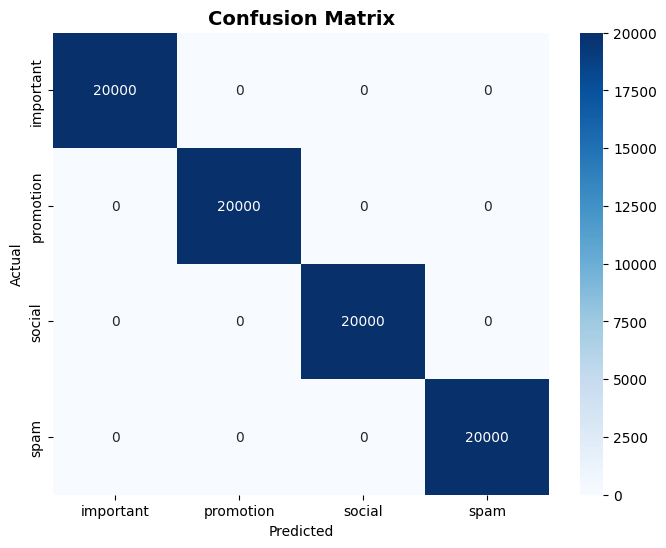


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   important       1.00      1.00      1.00     20000
   promotion       1.00      1.00      1.00     20000
      social       1.00      1.00      1.00     20000
        spam       1.00      1.00      1.00     20000

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000



In [44]:
#Confusion Matrix and Classification Report.

# Define y_pred first
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('figures/confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\n📋 CLASSIFICATION REPORT:")
print("="*50)
print(classification_report(y_test, y_pred, target_names=le.classes_))

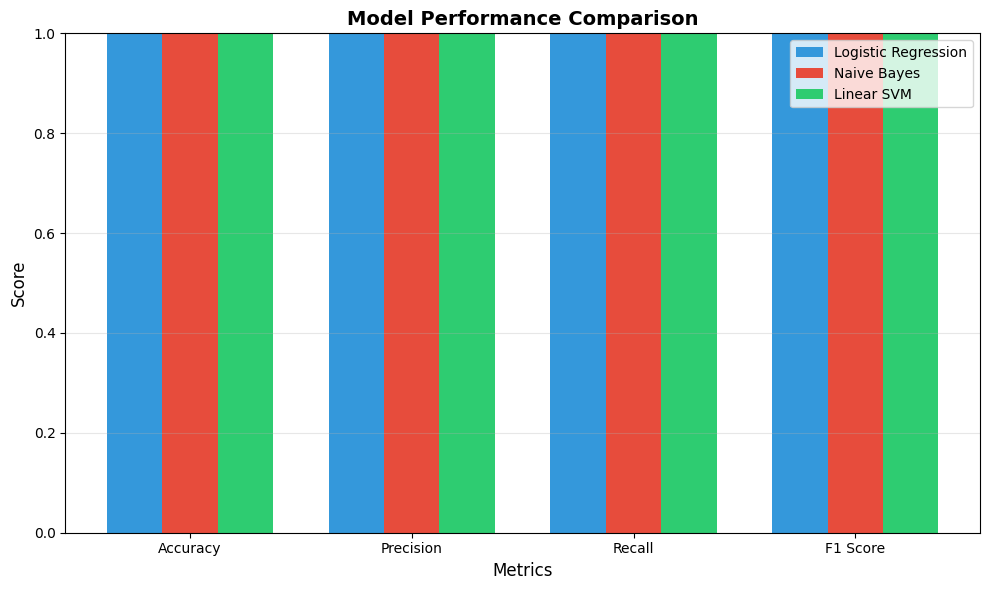

In [45]:
# Model Comparison Bar Chart to visualize the performance of all the models
plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model_name, scores) in enumerate(results.items()):
    values = [scores[m] for m in metrics]
    plt.bar(x + i*width, values, width, label=model_name, color=colors[i])

plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x + width, metrics)
plt.legend()
plt.ylim(0, 1)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()

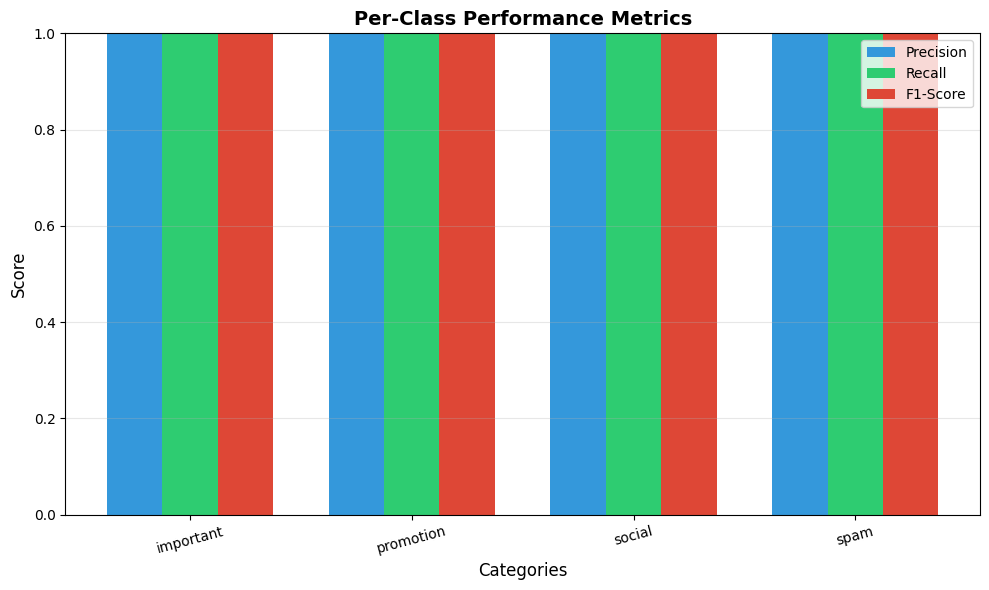

In [46]:
# Per-Class Performance Metrics to visualize the performance of the best model for each class

precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(le.classes_))
width = 0.25

ax.bar(x - width, precision, width, label='Precision', color='#3498db')
ax.bar(x, recall, width, label='Recall', color='#2ecc71')
ax.bar(x + width, fscore, width, label='F1-Score', color="#de4736")

ax.set_xlabel('Categories', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=15)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/per_class_performance.png', dpi=150)
plt.show()

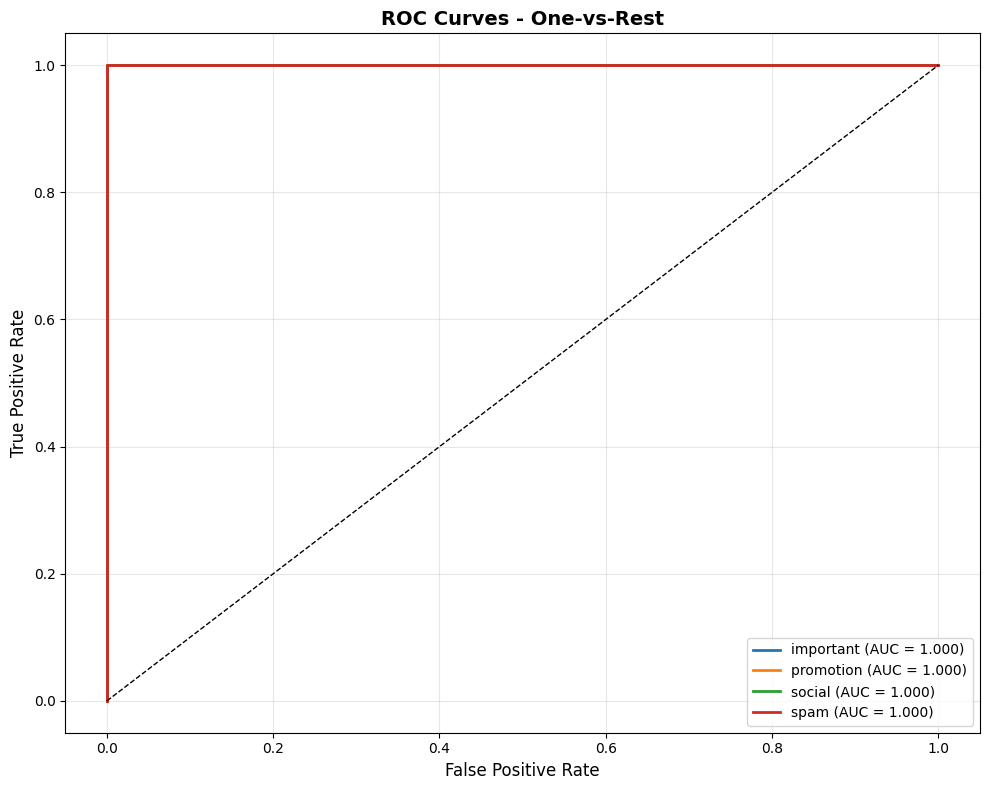

In [47]:
# ROC Curves for each class to visualize the performance of the best model for each class

if hasattr(best_model, 'predict_proba'):
    plt.figure(figsize=(10, 8))
    y_prob = best_model.predict_proba(X_test)
    
    for i, category in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{category} (AUC = {roc_auc:.3f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - One-vs-Rest', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/roc_curves.png', dpi=150)
    plt.show()

step 11: Top keywords per category to visualize the most import features of each class.

In [48]:
# Top keywords per category to visualize the most important features for each class based on the coefficients of the best model.
feature_names = vectorizer.get_feature_names_out()

if hasattr(best_model, 'coef_'):
    for i, category in enumerate(le.classes_):
        coef = best_model.coef_[i]
        top_idx = np.argsort(coef)[-10:][::-1]
        top_words = [feature_names[idx] for idx in top_idx]
        print(f"\n{category}: {', '.join(top_words)}")


important: let catch, tomorrow, update, project update, meeting tomorrow, catch, let, project, meeting, meet tomorrow

promotion: exclusive offer, miss exclusive, exclusive, miss, offer, discount, special offer, offer inside, sale today, big sale

social: check notification, notification, check, request, friend request, new friend, like post, post, someone like, friend

spam: limited, limited time, time offer, iphone, free iphone, win free, win, free, time, winwinwin


step 12: prediction system 

In [49]:
# Prediction function with improved short/long text handling.

def predict_email(text, threshold=0.6):
    """
    Predict email category with confidence score
    Handles short and long texts appropriately
    """
    # Handle empty input
    if not text or str(text).strip() == "":
        return {
            'category': 'ERROR', 
            'confidence': 0.0, 
            'display': '❌ ERROR', 
            'message': 'Empty input'
        }
    
    # Handle very short text (< 10 chars)
    if len(text.strip()) < 10:
        return {
            'category': 'UNCERTAIN', 
            'confidence': 0.0, 
            'display': '⚠️ UNCERTAIN', 
            'message': f'Text too short (minimum 10 characters needed). You entered {len(text.strip())} characters.'
        }
    
    # Handle long text (> 5000 chars) - truncate
    if len(text) > 5000:
        text = text[:5000]
    
    # Preprocess
    cleaned = preprocess_text(text)
    
    if len(cleaned.split()) < 2:
        return {
            'category': 'UNCERTAIN', 
            'confidence': 0.0, 
            'display': '⚠️ UNCERTAIN', 
            'message': 'Text quality too low after preprocessing'
        }
    
    # Vectorize and predict
    X_input = vectorizer.transform([cleaned])
    
    pred = best_model.predict(X_input)[0]
    proba = best_model.predict_proba(X_input)[0]
    confidence = max(proba)
    
    # Apply threshold
    if confidence < threshold:
        category = "UNCERTAIN"
        message = f"Low confidence prediction ({confidence:.1%} < {threshold:.0%})"
    else:
        category = le.inverse_transform([pred])[0]
        message = None
    
    # Add emoji for display
    emoji_map = {
        'Spam': '🚫', 
        'Promotion': '📢', 
        'Social': '👥', 
        'Important': '⭐', 
        'UNCERTAIN': '⚠️',
        'ERROR': '❌'
    }
    
    return {
        'category': category,
        'display': f"{emoji_map.get(category, '')} {category}",
        'confidence': confidence,
        'message': message,
        'all_probabilities': {le.classes_[i]: float(p) for i, p in enumerate(proba)}
    }

# Test the function with various inputs
print("\n" + "="*50)
print("📝 TESTING PREDICTION FUNCTION")
print("="*50)

test_cases = [
    ("", "Empty"),
    ("Hi", "Very Short"),
    ("WINNER! You won $1000! Click here!!!", "Spam"),
    ("FLAT 50% OFF on all products! Limited time!", "Promotion"),
    ("Your friend John commented on your photo", "Social"),
    ("Meeting scheduled for tomorrow at 10 AM", "Important"),
    ("A" * 6000, "Very Long")
]

for text, description in test_cases:
    result = predict_email(text)
    status = "⚠️" if result['confidence'] < 0.6 else "✅"
    
    # Handle very long text display
    display_text = text[:40] + "..." if len(text) > 40 else text
    if not text:
        display_text = "[Empty]"
    
    print(f"\n{status} {description}:")
    print(f"   Input: {display_text}")
    print(f"   Result: {result['display']}")
    print(f"   Confidence: {result['confidence']:.2%}")
    if result['message']:
        print(f"   Note: {result['message']}")


📝 TESTING PREDICTION FUNCTION

⚠️ Empty:
   Input: [Empty]
   Result: ❌ ERROR
   Confidence: 0.00%
   Note: Empty input

⚠️ Very Short:
   Input: Hi
   Result: ⚠️ UNCERTAIN
   Confidence: 0.00%
   Note: Text too short (minimum 10 characters needed). You entered 2 characters.

✅ Spam:
   Input: WINNER! You won $1000! Click here!!!
   Result:  spam
   Confidence: 99.14%

✅ Promotion:
   Input: FLAT 50% OFF on all products! Limited ti...
   Result:  spam
   Confidence: 99.97%

✅ Social:
   Input: Your friend John commented on your photo
   Result:  social
   Confidence: 100.00%

✅ Important:
   Input: Meeting scheduled for tomorrow at 10 AM
   Result:  important
   Confidence: 100.00%

⚠️ Very Long:
   Input: AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...
   Result: ⚠️ UNCERTAIN
   Confidence: 0.00%
   Note: Text quality too low after preprocessing


step 13: Batch prediction system for CSV files etc

In [50]:
#Batch prediction system with progress indicator.

def batch_predict(input_file, output_file, threshold=0.6):
    """
    Batch predict emails from CSV file
    Shows progress and handles errors gracefully
    """
    if not os.path.exists(input_file):
        print(f"❌ File not found: {input_file}")
        return None
    
    # Load CSV
    df = pd.read_csv(input_file)
    print(f"\n📊 Loaded {len(df)} rows from {input_file}")
    
    # Check for text column
    if 'text' not in df.columns:
        print("❌ CSV must have a 'text' column")
        print(f"   Available columns: {df.columns.tolist()}")
        return None
    
    # Process each row with progress
    results = []
    total = len(df)
    
    print("\n⏳ Processing emails...")
    for idx, text in enumerate(df['text'], 1):
        result = predict_email(str(text), threshold)
        results.append(result)
        
        # Show progress every 100 rows
        if idx % 100 == 0 or idx == total:
            print(f"   Progress: {idx}/{total} ({idx/total*100:.1f}%)")
    
    # Add results to dataframe
    df['prediction'] = [r['category'] for r in results]
    df['confidence'] = [r['confidence'] for r in results]
    df['display'] = [r['display'] for r in results]
    
    # Save to CSV
    df.to_csv(output_file, index=False)
    
    # Print summary
    print(f"\n✅ Results saved to: {output_file}")
    print("\n📊 SUMMARY:")
    print(f"   Total emails: {len(df)}")
    print(f"   ✅ REAL/Important: {(df['prediction'] == 'Important').sum()}")
    print(f"   👥 Social: {(df['prediction'] == 'Social').sum()}")
    print(f"   📢 Promotion: {(df['prediction'] == 'Promotion').sum()}")
    print(f"   🚫 Spam: {(df['prediction'] == 'Spam').sum()}")
    print(f"   ⚠️ Uncertain: {(df['prediction'] == 'UNCERTAIN').sum()}")
    print(f"   ❌ Errors: {(df['prediction'] == 'ERROR').sum()}")
    print(f"   Average confidence: {df['confidence'].mean():.2%}")
    
    return df

# Example usage (commented out)
# batch_predict("batch_input.csv", "batch_output.csv")

step 14: CLI meanu

In [51]:
#Complete CLI Menu System

def main_menu():
    """Interactive CLI menu with all features"""
    current_threshold = 0.6
    
    while True:
        print("\n" + "="*50)
        print("📧 EMAIL CLASSIFICATION SYSTEM")
        print("="*50)
        print(" 1. 🔍 Classify Single Email")
        print(" 2. 📁 Batch Process CSV File")
        print(" 3. 📊 View Model Performance")
        print(" 4. 🔑 View Top Keywords per Category")
        print(" 5. ⚙️  Change Confidence Threshold")
        print(" 6. 🧪 Test with Sample Emails")
        print(" 7. ❌ Exit")
        print("="*50)
        
        choice = input("\n👉 Enter choice (1-7): ").strip()
        
        if choice == '1':
            print("\n" + "-"*40)
            text = input("📧 Enter email content: ").strip()
            if not text:
                print("❌ No input provided")
                continue
            
            result = predict_email(text, current_threshold)
            
            print(f"\n📊 Result: {result['display']}")
            print(f"📈 Confidence: {result['confidence']:.2%}")
            
            # Show confidence bar
            bar_len = 20
            filled = int(result['confidence'] * bar_len)
            bar = '█' * filled + '░' * (bar_len - filled)
            print(f"Confidence: [{bar}]")
            
            if result['message']:
                print(f"⚠️ Note: {result['message']}")
            
            # Show top probabilities
            print("\n📊 Probability breakdown:")
            sorted_probs = sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True)
            for cat, prob in sorted_probs[:2]:
                print(f"   {cat}: {prob:.2%}")
        
        elif choice == '2':
            print("\n" + "-"*40)
            inp = input("📂 Input CSV file path: ").strip()
            if not inp:
                inp = "batch_input.csv"
            
            out = input("💾 Output CSV file path: ").strip()
            if not out:
                from datetime import datetime
                out = f"batch_output_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
            
            batch_predict(inp, out, current_threshold)
        
        elif choice == '3':
            print("\n" + "="*50)
            print("📊 MODEL PERFORMANCE")
            print("="*50)
            print(results_df.to_string())
        
        elif choice == '4':
            print("\n" + "="*50)
            print("🔑 TOP KEYWORDS PER CATEGORY")
            print("="*50)
            if hasattr(best_model, 'coef_'):
                feature_names = vectorizer.get_feature_names_out()
                for i, category in enumerate(le.classes_):
                    coef = best_model.coef_[i]
                    top_idx = np.argsort(coef)[-10:][::-1]
                    top_words = [feature_names[idx] for idx in top_idx]
                    print(f"\n📌 {category}:")
                    print(f"   {', '.join(top_words)}")
            else:
                print("Feature importance not available for this model")
        
        elif choice == '5':
            print("\n" + "-"*40)
            try:
                print(f"Current threshold: {current_threshold}")
                new_thresh = float(input("New threshold (0.5-0.9): "))
                if 0.5 <= new_thresh <= 0.9:
                    current_threshold = new_thresh
                    print(f"✅ Threshold updated to {current_threshold}")
                else:
                    print("❌ Threshold must be between 0.5 and 0.9")
            except ValueError:
                print("❌ Invalid input. Please enter a number between 0.5 and 0.9")
        
        elif choice == '6':
            print("\n" + "="*50)
            print("🧪 TESTING WITH SAMPLES")
            print("="*50)
            
            samples = [
                ("Spam", "WINNER! You've won $1,000,000! Click here to claim!"),
                ("Promotion", "FLAT 50% OFF on all products! Use code SAVE50"),
                ("Social", "Your friend John commented on your photo"),
                ("Important", "Important: Team meeting tomorrow at 10 AM"),
                ("Very Short", "Hi")
            ]
            
            for name, sample in samples:
                result = predict_email(sample, current_threshold)
                status = "✅" if result['confidence'] >= current_threshold else "⚠️"
                print(f"\n{status} {name}:")
                print(f"   Text: {sample[:50]}...")
                print(f"   Result: {result['display']}")
                print(f"   Confidence: {result['confidence']:.2%}")
        
        elif choice == '7':
            print("\n👋 Thank you for using Email Classification System!")
            print("   Goodbye!")
            break
        
        else:
            print("❌ Invalid choice. Please enter 1-7")

# Run the menu
if __name__ == "__main__":
    main_menu()


📧 EMAIL CLASSIFICATION SYSTEM
 1. 🔍 Classify Single Email
 2. 📁 Batch Process CSV File
 3. 📊 View Model Performance
 4. 🔑 View Top Keywords per Category
 5. ⚙️  Change Confidence Threshold
 6. 🧪 Test with Sample Emails
 7. ❌ Exit

👋 Thank you for using Email Classification System!
   Goodbye!


Step 15: quick test on sample data

In [52]:
# Quick test to demonstrate the prediction function with various inputs, including edge cases for short and long texts.

print("\n🔮 Testing with examples:")
examples = [
    "Win free iPhone now! Click here",
    "50% off sale today only",
    "Your friend liked your post",
    "Board meeting at 3 PM tomorrow"
]

for ex in examples:
    result = predict_email(ex)
    print(f"{result['category']:12} ({result['confidence']:.2%}) - {ex[:40]}")


🔮 Testing with examples:
spam         (100.00%) - Win free iPhone now! Click here
promotion    (100.00%) - 50% off sale today only
social       (100.00%) - Your friend liked your post
important    (100.00%) - Board meeting at 3 PM tomorrow
